# **AI 600 Deep Learning Assignment 2**

In [37]:
from google.colab import drive
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim
import torch.nn.functional as F

In [38]:
VAL_SIZE = 128
TRAIN_SIZE = 128
TEST_SIZE = 128
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
EPOCHS = 40
PANCAKE_LAYERS = [1024, 1024]
TOWER_LAYERS = [256, 256, 256, 256, 256, 256]
def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total_params


Using device: cuda


In [3]:
drive.mount('/content/drive',force_remount=True)

Mounted at /content/drive


In [39]:
with np.load('/content/drive/MyDrive/AI600Assignment2/quickdraw_train.npz') as data:
  X = data['x_train'].astype(np.float32)
  Y = data['y_train']
  class_names = data['class_names']
with np.load('/content/drive/MyDrive/AI600Assignment2/quickdraw_test.npz') as data:
  X_test = data['test_images']

In [40]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_scaled.shape, X_test.shape   

((60000, 784), (15000, 784))

In [41]:
X_train, X_val, Y_train, Y_val = train_test_split(X_scaled, Y, test_size=0.2, random_state=42)

X_train_tensor = torch.from_numpy(X_train)
Y_train_tensor = torch.from_numpy(Y_train).long()
train_dataset = TensorDataset(X_train_tensor, Y_train_tensor)
train_loader = DataLoader(dataset=train_dataset, batch_size=TRAIN_SIZE, shuffle=True)

X_val_tensor = torch.from_numpy(X_val)
Y_val_tensor = torch.from_numpy(Y_val).long()
val_dataset = TensorDataset(X_val_tensor, Y_val_tensor)
val_loader = DataLoader(dataset=val_dataset, batch_size=VAL_SIZE, shuffle=False)

X_test_float = X_test.astype(np.float32)
X_test_scaled = scaler.transform(X_test_float)
X_test_tensor = torch.from_numpy(X_test_scaled)
test_dataset = TensorDataset(X_test_tensor)
test_loader = DataLoader(dataset=test_dataset, batch_size=TEST_SIZE, shuffle=False)


In [42]:
class Pancake(nn.Module):
  def __init__(self, input_size=784, num_classes=15, hidden_layers=PANCAKE_LAYERS):
    super(Pancake, self).__init__()
    layers = [nn.Flatten()]
    current_dim = input_size
    for h_dim in hidden_layers:
        layers.append(nn.Linear(current_dim, h_dim))
        layers.append(nn.ReLU())
        current_dim = h_dim
    layers.append(nn.Linear(current_dim, num_classes))
    self.network = nn.Sequential(*layers)

  def forward(self, x):
    return self.network(x)


In [43]:
model = Pancake().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

In [44]:
best_val_acc = 0.0

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, dim=1)
        correct_train += (preds == targets).sum().item()
        total_train += targets.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = correct_train / total_train

    model.eval()
    val_correct = 0
    val_total = 0
    val_loss = 0.0

    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            logits = model(inputs)
            loss = criterion(logits, targets)
            
            val_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(logits, dim=1)
            val_correct += (preds == targets).sum().item()
            val_total += targets.size(0)

    val_accuracy = val_correct / val_total if val_total > 0 else 0
    val_loss_avg = val_loss / len(val_loader.dataset) if len(val_loader.dataset) > 0 else 0

    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        best_epoch = epoch + 1
        torch.save(model.state_dict(), 'best_model_pancake.pth')

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc*100:.2f}%")
    print(f"Val Loss:   {val_loss_avg:.4f} | Val Acc:   {val_accuracy*100:.2f}%")
    print("-" * 30)
print(f"Best Validation Accuracy: {best_val_acc*100:.2f}% at epoch {best_epoch}")

Epoch 1/40
Train Loss: 1.1163 | Train Acc: 63.52%
Val Loss:   0.8869 | Val Acc:   70.49%
------------------------------
Epoch 2/40
Train Loss: 0.7954 | Train Acc: 73.91%
Val Loss:   0.7977 | Val Acc:   74.33%
------------------------------
Epoch 3/40
Train Loss: 0.6484 | Train Acc: 78.35%
Val Loss:   0.7660 | Val Acc:   75.29%
------------------------------
Epoch 4/40
Train Loss: 0.5337 | Train Acc: 81.96%
Val Loss:   0.7464 | Val Acc:   76.27%
------------------------------
Epoch 5/40
Train Loss: 0.4363 | Train Acc: 85.08%
Val Loss:   0.7776 | Val Acc:   76.24%
------------------------------
Epoch 6/40
Train Loss: 0.3515 | Train Acc: 87.77%
Val Loss:   0.8284 | Val Acc:   76.39%
------------------------------
Epoch 7/40
Train Loss: 0.2783 | Train Acc: 90.21%
Val Loss:   0.8721 | Val Acc:   75.83%
------------------------------
Epoch 8/40
Train Loss: 0.2181 | Train Acc: 92.24%
Val Loss:   0.9756 | Val Acc:   75.89%
------------------------------
Epoch 9/40
Train Loss: 0.1705 | Train Ac

In [45]:
count_parameters(model)

1868815

In [46]:
class Tower(nn.Module):
  def __init__(self, input_size=784, num_classes=15, hidden_layers=TOWER_LAYERS):
    super(Tower, self).__init__()
    layers = [nn.Flatten()]
    current_dim = input_size
    for h_dim in hidden_layers:
        layers.append(nn.Linear(current_dim, h_dim))
        layers.append(nn.ReLU())
        current_dim = h_dim
    layers.append(nn.Linear(current_dim, num_classes))
    self.network = nn.Sequential(*layers)


  def forward(self, x):
      return self.network(x)


In [ ]:
model = Tower().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

In [48]:
best_val_acc = 0.0

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, dim=1)
        correct_train += (preds == targets).sum().item()
        total_train += targets.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = correct_train / total_train

    model.eval()
    val_correct = 0
    val_total = 0
    val_loss = 0.0

    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            logits = model(inputs)
            loss = criterion(logits, targets)
            
            val_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(logits, dim=1)
            val_correct += (preds == targets).sum().item()
            val_total += targets.size(0)

    val_accuracy = val_correct / val_total if val_total > 0 else 0
    val_loss_avg = val_loss / len(val_loader.dataset) if len(val_loader.dataset) > 0 else 0

    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        best_epoch = epoch + 1
        torch.save(model.state_dict(), 'best_model_tower.pth')

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc*100:.2f}%")
    print(f"Val Loss:   {val_loss_avg:.4f} | Val Acc:   {val_accuracy*100:.2f}%")
    print("-" * 30)
print(f"Best Validation Accuracy: {best_val_acc*100:.2f}% at epoch {best_epoch}")

Epoch 1/40
Train Loss: 1.4016 | Train Acc: 51.28%
Val Loss:   1.0999 | Val Acc:   63.14%
------------------------------
Epoch 2/40
Train Loss: 0.9757 | Train Acc: 67.25%
Val Loss:   0.9364 | Val Acc:   68.35%
------------------------------
Epoch 3/40
Train Loss: 0.8426 | Train Acc: 71.80%
Val Loss:   0.8769 | Val Acc:   70.58%
------------------------------
Epoch 4/40
Train Loss: 0.7545 | Train Acc: 74.50%
Val Loss:   0.8360 | Val Acc:   72.32%
------------------------------
Epoch 5/40
Train Loss: 0.6903 | Train Acc: 76.76%
Val Loss:   0.8347 | Val Acc:   73.01%
------------------------------
Epoch 6/40
Train Loss: 0.6347 | Train Acc: 78.76%
Val Loss:   0.8136 | Val Acc:   73.78%
------------------------------
Epoch 7/40
Train Loss: 0.5847 | Train Acc: 80.19%
Val Loss:   0.8178 | Val Acc:   74.08%
------------------------------
Epoch 8/40
Train Loss: 0.5416 | Train Acc: 81.75%
Val Loss:   0.8377 | Val Acc:   74.08%
------------------------------
Epoch 9/40
Train Loss: 0.4988 | Train Ac

In [49]:
count_parameters(model)

533775

In [50]:
CHAMPION_LAYERS = [512, 256, 128]

In [86]:
class Champion(nn.Module):
  def __init__(self, input_size=784, num_classes=15, hidden_layers=CHAMPION_LAYERS):
    super(Champion, self).__init__()
    layers = [nn.Flatten()]
    current_dim = input_size
    for h_dim in hidden_layers:
        layers.append(nn.Linear(current_dim, h_dim))
        layers.append(nn.BatchNorm1d(h_dim))
        # layers.append(nn.ReLU()) Iteration 4 removal
        layers.append(nn.GELU()) # Iteration 4 addition
        if h_dim == 512:  # Add dropout after the first hidden layer
            layers.append(nn.Dropout(0.2))
        if h_dim == 256:  # Add dropout after the second hidden layer
          layers.append(nn.Dropout(0.3))
        if h_dim == 128:  # Add dropout after the third hidden layer
          layers.append(nn.Dropout(0.4))
        current_dim = h_dim
    layers.append(nn.Linear(current_dim, num_classes))
    self.network = nn.Sequential(*layers)

  def forward(self, x):
    return self.network(x)

In [52]:
# First train the champion model with the same training loop as before, then evaluate on the validation set.
# CHAMPION_LAYERS = [512, 256, 128] for first iteration, no changes other than that.
model = Champion().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

In [53]:
best_val_acc = 0.0

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, dim=1)
        correct_train += (preds == targets).sum().item()
        total_train += targets.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = correct_train / total_train

    model.eval()
    val_correct = 0
    val_total = 0
    val_loss = 0.0

    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            logits = model(inputs)
            loss = criterion(logits, targets)
            
            val_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(logits, dim=1)
            val_correct += (preds == targets).sum().item()
            val_total += targets.size(0)

    val_accuracy = val_correct / val_total if val_total > 0 else 0
    val_loss_avg = val_loss / len(val_loader.dataset) if len(val_loader.dataset) > 0 else 0

    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        best_epoch = epoch + 1
        torch.save(model.state_dict(), 'best_model_champion1.pth')

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc*100:.2f}%")
    print(f"Val Loss:   {val_loss_avg:.4f} | Val Acc:   {val_accuracy*100:.2f}%")
    print("-" * 30)
print(f"Best Validation Accuracy: {best_val_acc*100:.2f}% at epoch {best_epoch}")

Epoch 1/40
Train Loss: 1.2527 | Train Acc: 58.49%
Val Loss:   0.9834 | Val Acc:   67.44%
------------------------------
Epoch 2/40
Train Loss: 0.8878 | Train Acc: 70.75%
Val Loss:   0.8624 | Val Acc:   71.27%
------------------------------
Epoch 3/40
Train Loss: 0.7542 | Train Acc: 75.08%
Val Loss:   0.8033 | Val Acc:   73.84%
------------------------------
Epoch 4/40
Train Loss: 0.6544 | Train Acc: 78.38%
Val Loss:   0.7575 | Val Acc:   75.38%
------------------------------
Epoch 5/40
Train Loss: 0.5710 | Train Acc: 80.83%
Val Loss:   0.7718 | Val Acc:   75.25%
------------------------------
Epoch 6/40
Train Loss: 0.4984 | Train Acc: 83.09%
Val Loss:   0.7773 | Val Acc:   75.56%
------------------------------
Epoch 7/40
Train Loss: 0.4372 | Train Acc: 85.08%
Val Loss:   0.7854 | Val Acc:   75.54%
------------------------------
Epoch 8/40
Train Loss: 0.3767 | Train Acc: 87.00%
Val Loss:   0.8242 | Val Acc:   75.63%
------------------------------
Epoch 9/40
Train Loss: 0.3219 | Train Ac

In [54]:
# Modify the champion model architecture and/or training procedure to improve validation accuracy.
# First changing the optimizer to AdamW, then will experiment with other changes if needed.
model = Champion().to(device)
optimizer = optim.AdamW(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

In [55]:
best_val_acc = 0.0

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, dim=1)
        correct_train += (preds == targets).sum().item()
        total_train += targets.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = correct_train / total_train

    model.eval()
    val_correct = 0
    val_total = 0
    val_loss = 0.0

    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            logits = model(inputs)
            loss = criterion(logits, targets)
            
            val_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(logits, dim=1)
            val_correct += (preds == targets).sum().item()
            val_total += targets.size(0)

    val_accuracy = val_correct / val_total if val_total > 0 else 0
    val_loss_avg = val_loss / len(val_loader.dataset) if len(val_loader.dataset) > 0 else 0

    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        best_epoch = epoch + 1
        torch.save(model.state_dict(), 'best_model_champion2.pth')

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc*100:.2f}%")
    print(f"Val Loss:   {val_loss_avg:.4f} | Val Acc:   {val_accuracy*100:.2f}%")
    print("-" * 30)
print(f"Best Validation Accuracy: {best_val_acc*100:.2f}% at epoch {best_epoch}")

Epoch 1/40
Train Loss: 1.2674 | Train Acc: 58.56%
Val Loss:   0.9721 | Val Acc:   68.06%
------------------------------
Epoch 2/40
Train Loss: 0.9028 | Train Acc: 70.34%
Val Loss:   0.8800 | Val Acc:   70.97%
------------------------------
Epoch 3/40
Train Loss: 0.7733 | Train Acc: 74.61%
Val Loss:   0.8070 | Val Acc:   73.66%
------------------------------
Epoch 4/40
Train Loss: 0.6678 | Train Acc: 77.90%
Val Loss:   0.7810 | Val Acc:   74.31%
------------------------------
Epoch 5/40
Train Loss: 0.5837 | Train Acc: 80.50%
Val Loss:   0.7733 | Val Acc:   75.56%
------------------------------
Epoch 6/40
Train Loss: 0.5140 | Train Acc: 82.76%
Val Loss:   0.8073 | Val Acc:   74.71%
------------------------------
Epoch 7/40
Train Loss: 0.4515 | Train Acc: 84.64%
Val Loss:   0.7707 | Val Acc:   76.31%
------------------------------
Epoch 8/40
Train Loss: 0.3921 | Train Acc: 86.65%
Val Loss:   0.8110 | Val Acc:   76.45%
------------------------------
Epoch 9/40
Train Loss: 0.3415 | Train Ac

In [56]:
count_parameters(model)

568079

In [60]:
# Added Batch Normalization, then will experiment with other changes if needed.
model = Champion().to(device)
optimizer = optim.AdamW(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

In [61]:
best_val_acc = 0.0

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, dim=1)
        correct_train += (preds == targets).sum().item()
        total_train += targets.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = correct_train / total_train

    model.eval()
    val_correct = 0
    val_total = 0
    val_loss = 0.0

    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            logits = model(inputs)
            loss = criterion(logits, targets)
            
            val_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(logits, dim=1)
            val_correct += (preds == targets).sum().item()
            val_total += targets.size(0)

    val_accuracy = val_correct / val_total if val_total > 0 else 0
    val_loss_avg = val_loss / len(val_loader.dataset) if len(val_loader.dataset) > 0 else 0

    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        best_epoch = epoch + 1
        torch.save(model.state_dict(), 'best_model_champion3.pth')

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc*100:.2f}%")
    print(f"Val Loss:   {val_loss_avg:.4f} | Val Acc:   {val_accuracy*100:.2f}%")
    print("-" * 30)
print(f"Best Validation Accuracy: {best_val_acc*100:.2f}% at epoch {best_epoch}")

Epoch 1/40
Train Loss: 1.0179 | Train Acc: 66.94%
Val Loss:   0.8072 | Val Acc:   72.97%
------------------------------
Epoch 2/40
Train Loss: 0.7313 | Train Acc: 75.65%
Val Loss:   0.7443 | Val Acc:   74.92%
------------------------------
Epoch 3/40
Train Loss: 0.6017 | Train Acc: 79.84%
Val Loss:   0.7239 | Val Acc:   76.02%
------------------------------
Epoch 4/40
Train Loss: 0.5116 | Train Acc: 82.80%
Val Loss:   0.6947 | Val Acc:   77.43%
------------------------------
Epoch 5/40
Train Loss: 0.4280 | Train Acc: 85.53%
Val Loss:   0.7310 | Val Acc:   77.31%
------------------------------
Epoch 6/40
Train Loss: 0.3613 | Train Acc: 87.66%
Val Loss:   0.7473 | Val Acc:   77.99%
------------------------------
Epoch 7/40
Train Loss: 0.2963 | Train Acc: 89.71%
Val Loss:   0.7947 | Val Acc:   77.14%
------------------------------
Epoch 8/40
Train Loss: 0.2424 | Train Acc: 91.77%
Val Loss:   0.8374 | Val Acc:   76.57%
------------------------------
Epoch 9/40
Train Loss: 0.2012 | Train Ac

In [63]:
# Added Dropout p=0.4, then will experiment with other changes if needed.
model = Champion().to(device)
optimizer = optim.AdamW(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

In [64]:
best_val_acc = 0.0

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, dim=1)
        correct_train += (preds == targets).sum().item()
        total_train += targets.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = correct_train / total_train

    model.eval()
    val_correct = 0
    val_total = 0
    val_loss = 0.0

    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            logits = model(inputs)
            loss = criterion(logits, targets)
            
            val_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(logits, dim=1)
            val_correct += (preds == targets).sum().item()
            val_total += targets.size(0)

    val_accuracy = val_correct / val_total if val_total > 0 else 0
    val_loss_avg = val_loss / len(val_loader.dataset) if len(val_loader.dataset) > 0 else 0

    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        best_epoch = epoch + 1
        torch.save(model.state_dict(), 'best_model_champion4.pth')

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc*100:.2f}%")
    print(f"Val Loss:   {val_loss_avg:.4f} | Val Acc:   {val_accuracy*100:.2f}%")
    print("-" * 30)
print(f"Best Validation Accuracy: {best_val_acc*100:.2f}% at epoch {best_epoch}")

Epoch 1/40
Train Loss: 1.3190 | Train Acc: 57.65%
Val Loss:   0.9260 | Val Acc:   69.38%
------------------------------
Epoch 2/40
Train Loss: 1.0145 | Train Acc: 66.55%
Val Loss:   0.8369 | Val Acc:   71.97%
------------------------------
Epoch 3/40
Train Loss: 0.9311 | Train Acc: 69.27%
Val Loss:   0.7876 | Val Acc:   73.62%
------------------------------
Epoch 4/40
Train Loss: 0.8767 | Train Acc: 71.03%
Val Loss:   0.7658 | Val Acc:   74.18%
------------------------------
Epoch 5/40
Train Loss: 0.8292 | Train Acc: 72.59%
Val Loss:   0.7377 | Val Acc:   75.30%
------------------------------
Epoch 6/40
Train Loss: 0.7965 | Train Acc: 73.77%
Val Loss:   0.7183 | Val Acc:   76.07%
------------------------------
Epoch 7/40
Train Loss: 0.7636 | Train Acc: 74.59%
Val Loss:   0.7059 | Val Acc:   76.55%
------------------------------
Epoch 8/40
Train Loss: 0.7338 | Train Acc: 75.68%
Val Loss:   0.6953 | Val Acc:   77.21%
------------------------------
Epoch 9/40
Train Loss: 0.7080 | Train Ac

In [66]:
# Added GeLu(), then will experiment with other changes if needed.
model = Champion().to(device)
optimizer = optim.AdamW(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

In [67]:
best_val_acc = 0.0

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, dim=1)
        correct_train += (preds == targets).sum().item()
        total_train += targets.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = correct_train / total_train

    model.eval()
    val_correct = 0
    val_total = 0
    val_loss = 0.0

    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            logits = model(inputs)
            loss = criterion(logits, targets)
            
            val_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(logits, dim=1)
            val_correct += (preds == targets).sum().item()
            val_total += targets.size(0)

    val_accuracy = val_correct / val_total if val_total > 0 else 0
    val_loss_avg = val_loss / len(val_loader.dataset) if len(val_loader.dataset) > 0 else 0

    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        best_epoch = epoch + 1
        torch.save(model.state_dict(), 'best_model_champion5.pth')

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc*100:.2f}%")
    print(f"Val Loss:   {val_loss_avg:.4f} | Val Acc:   {val_accuracy*100:.2f}%")
    print("-" * 30)
print(f"Best Validation Accuracy: {best_val_acc*100:.2f}% at epoch {best_epoch}")

Epoch 1/40
Train Loss: 1.2580 | Train Acc: 59.29%
Val Loss:   0.8936 | Val Acc:   70.28%
------------------------------
Epoch 2/40
Train Loss: 0.9641 | Train Acc: 68.21%
Val Loss:   0.8097 | Val Acc:   72.59%
------------------------------
Epoch 3/40
Train Loss: 0.8749 | Train Acc: 71.01%
Val Loss:   0.7598 | Val Acc:   74.58%
------------------------------
Epoch 4/40
Train Loss: 0.8107 | Train Acc: 73.12%
Val Loss:   0.7273 | Val Acc:   75.92%
------------------------------
Epoch 5/40
Train Loss: 0.7600 | Train Acc: 74.93%
Val Loss:   0.7068 | Val Acc:   76.47%
------------------------------
Epoch 6/40
Train Loss: 0.7204 | Train Acc: 76.19%
Val Loss:   0.6828 | Val Acc:   77.48%
------------------------------
Epoch 7/40
Train Loss: 0.6891 | Train Acc: 77.15%
Val Loss:   0.6730 | Val Acc:   77.53%
------------------------------
Epoch 8/40
Train Loss: 0.6508 | Train Acc: 78.36%
Val Loss:   0.6673 | Val Acc:   78.10%
------------------------------
Epoch 9/40
Train Loss: 0.6257 | Train Ac

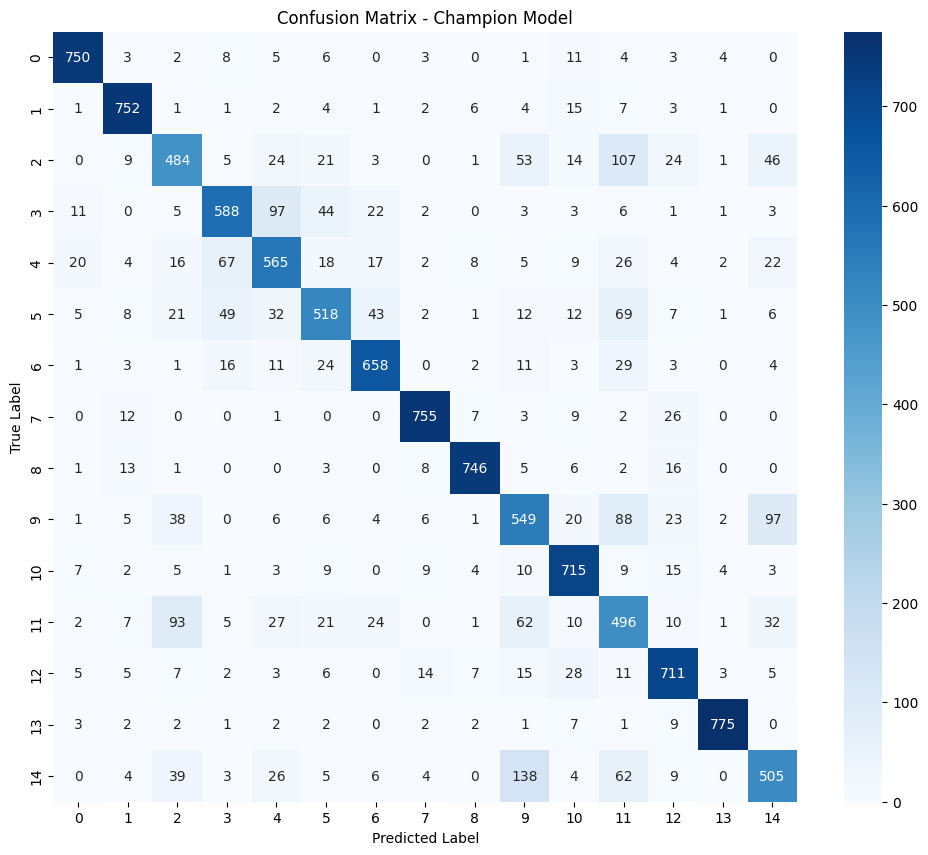

Top 2 Most Confused Pairs:
True Class 14 was predicted as Class 9 -> 138 times
True Class 2 was predicted as Class 11 -> 107 times


In [68]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
# 1. Load your best saved weights into the Champion model
model = Champion() # Ensure your CHAMPION_LAYERS are [512, 256, 128]
model.load_state_dict(torch.load('best_model_champion4.pth'))
model.to(device)
model.eval()

all_preds = []
all_targets = []

# 2. Gather all predictions from the validation set
with torch.no_grad():
    for inputs, targets in val_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        preds = torch.argmax(outputs, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

# 3. Generate the Confusion Matrix
cm = confusion_matrix(all_targets, all_preds)

# Plotting
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Champion Model')
plt.show()

# 4. Find the Top 2 Confused Pairs
# Fill diagonal with 0s so we only look at mistakes
np.fill_diagonal(cm, 0)

# Flatten and get the indices of the highest errors
flat_cm = cm.flatten()
top_2_indices = flat_cm.argsort()[-2:][::-1]

print("Top 2 Most Confused Pairs:")
for idx in top_2_indices:
    true_class = idx // 15  # Assuming 15 classes
    pred_class = idx % 15
    mistakes = cm[true_class, pred_class]
    print(f"True Class {true_class} was predicted as Class {pred_class} -> {mistakes} times")

In [70]:
# Added LR Scheduler, then will experiment with other changes if needed.
model = Champion().to(device)
optimizer = optim.AdamW(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
criterion = nn.CrossEntropyLoss()

In [71]:
best_val_acc = 0.0

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, dim=1)
        correct_train += (preds == targets).sum().item()
        total_train += targets.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = correct_train / total_train

    model.eval()
    val_correct = 0
    val_total = 0
    val_loss = 0.0

    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            logits = model(inputs)
            loss = criterion(logits, targets)
            
            val_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(logits, dim=1)
            val_correct += (preds == targets).sum().item()
            val_total += targets.size(0)

    val_accuracy = val_correct / val_total if val_total > 0 else 0
    val_loss_avg = val_loss / len(val_loader.dataset) if len(val_loader.dataset) > 0 else 0

    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        best_epoch = epoch + 1
        torch.save(model.state_dict(), 'best_model_champion6.pth')
    val_loss_avg = val_loss / len(val_loader.dataset) if len(val_loader.dataset) > 0 else 0
    
    scheduler.step(val_loss_avg)
    
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Current Learning Rate: {current_lr}")
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc*100:.2f}%")
    print(f"Val Loss:   {val_loss_avg:.4f} | Val Acc:   {val_accuracy*100:.2f}%")
    print("-" * 30)
print(f"Best Validation Accuracy: {best_val_acc*100:.2f}% at epoch {best_epoch}")

Current Learning Rate: 0.001
Epoch 1/40
Train Loss: 1.2583 | Train Acc: 59.42%
Val Loss:   0.8938 | Val Acc:   69.58%
------------------------------
Current Learning Rate: 0.001
Epoch 2/40
Train Loss: 0.9663 | Train Acc: 68.03%
Val Loss:   0.8034 | Val Acc:   72.82%
------------------------------
Current Learning Rate: 0.001
Epoch 3/40
Train Loss: 0.8766 | Train Acc: 71.04%
Val Loss:   0.7586 | Val Acc:   74.27%
------------------------------
Current Learning Rate: 0.001
Epoch 4/40
Train Loss: 0.8137 | Train Acc: 73.04%
Val Loss:   0.7335 | Val Acc:   75.58%
------------------------------
Current Learning Rate: 0.001
Epoch 5/40
Train Loss: 0.7617 | Train Acc: 74.84%
Val Loss:   0.7043 | Val Acc:   76.53%
------------------------------
Current Learning Rate: 0.001
Epoch 6/40
Train Loss: 0.7159 | Train Acc: 76.30%
Val Loss:   0.6976 | Val Acc:   77.10%
------------------------------
Current Learning Rate: 0.001
Epoch 7/40
Train Loss: 0.6832 | Train Acc: 77.21%
Val Loss:   0.6741 | Val Ac

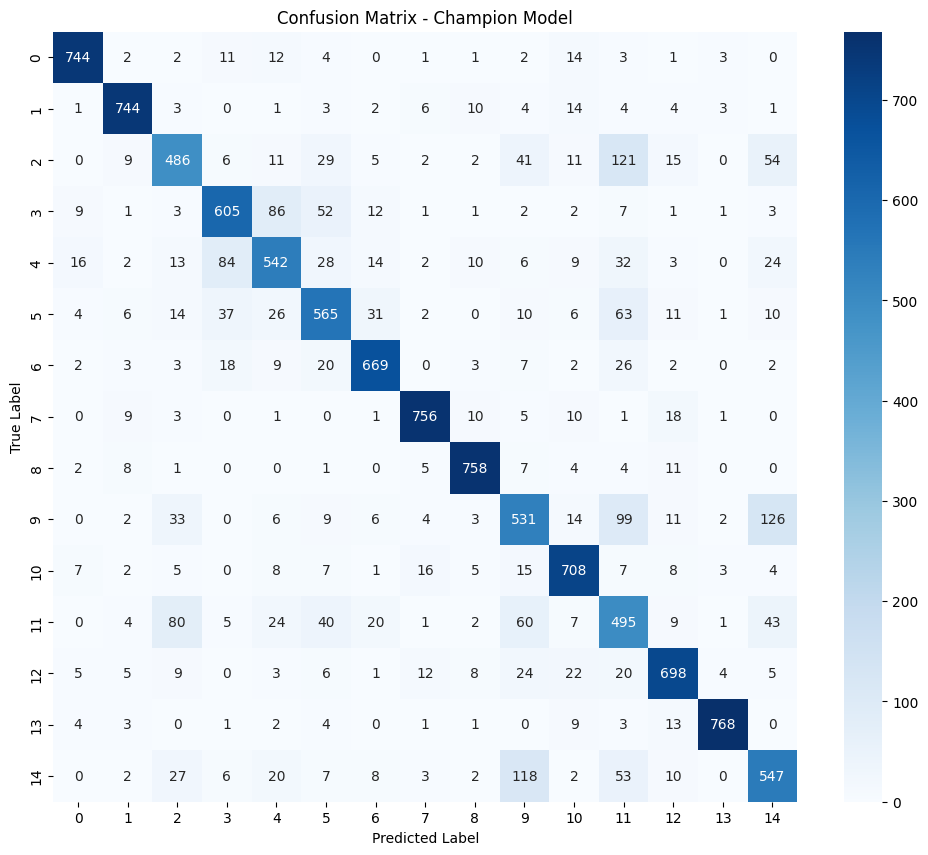

Top 2 Most Confused Pairs:
True Class 9 was predicted as Class 14 -> 126 times
True Class 2 was predicted as Class 11 -> 121 times


In [72]:
model = Champion()
model.load_state_dict(torch.load('best_model_champion6.pth'))
model.to(device)
model.eval()

all_preds = []
all_targets = []

# 2. Gather all predictions from the validation set
with torch.no_grad():
    for inputs, targets in val_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        preds = torch.argmax(outputs, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

# 3. Generate the Confusion Matrix
cm = confusion_matrix(all_targets, all_preds)

# Plotting
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Champion Model')
plt.show()

# 4. Find the Top 2 Confused Pairs
# Fill diagonal with 0s so we only look at mistakes
np.fill_diagonal(cm, 0)

# Flatten and get the indices of the highest errors
flat_cm = cm.flatten()
top_2_indices = flat_cm.argsort()[-2:][::-1]

print("Top 2 Most Confused Pairs:")
for idx in top_2_indices:
    true_class = idx // 15  # Assuming 15 classes
    pred_class = idx % 15
    mistakes = cm[true_class, pred_class]
    print(f"True Class {true_class} was predicted as Class {pred_class} -> {mistakes} times")

In [73]:
# Added label smoothing, then will experiment with other changes if needed.
model = Champion().to(device)
optimizer = optim.AdamW(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

In [74]:
best_val_acc = 0.0

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, dim=1)
        correct_train += (preds == targets).sum().item()
        total_train += targets.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = correct_train / total_train

    model.eval()
    val_correct = 0
    val_total = 0
    val_loss = 0.0

    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            logits = model(inputs)
            loss = criterion(logits, targets)
            
            val_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(logits, dim=1)
            val_correct += (preds == targets).sum().item()
            val_total += targets.size(0)

    val_accuracy = val_correct / val_total if val_total > 0 else 0
    val_loss_avg = val_loss / len(val_loader.dataset) if len(val_loader.dataset) > 0 else 0

    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        best_epoch = epoch + 1
        torch.save(model.state_dict(), 'best_model_champion7.pth')
    val_loss_avg = val_loss / len(val_loader.dataset) if len(val_loader.dataset) > 0 else 0
    
    scheduler.step(val_loss_avg)
    
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Current Learning Rate: {current_lr}")
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc*100:.2f}%")
    print(f"Val Loss:   {val_loss_avg:.4f} | Val Acc:   {val_accuracy*100:.2f}%")
    print("-" * 30)
print(f"Best Validation Accuracy: {best_val_acc*100:.2f}% at epoch {best_epoch}")

Current Learning Rate: 0.001
Epoch 1/40
Train Loss: 1.5639 | Train Acc: 59.85%
Val Loss:   1.2796 | Val Acc:   70.30%
------------------------------
Current Learning Rate: 0.001
Epoch 2/40
Train Loss: 1.3492 | Train Acc: 68.49%
Val Loss:   1.2161 | Val Acc:   73.02%
------------------------------
Current Learning Rate: 0.001
Epoch 3/40
Train Loss: 1.2819 | Train Acc: 71.15%
Val Loss:   1.1803 | Val Acc:   73.85%
------------------------------
Current Learning Rate: 0.001
Epoch 4/40
Train Loss: 1.2374 | Train Acc: 73.42%
Val Loss:   1.1584 | Val Acc:   75.20%
------------------------------
Current Learning Rate: 0.001
Epoch 5/40
Train Loss: 1.1996 | Train Acc: 74.75%
Val Loss:   1.1282 | Val Acc:   76.79%
------------------------------
Current Learning Rate: 0.001
Epoch 6/40
Train Loss: 1.1667 | Train Acc: 76.49%
Val Loss:   1.1172 | Val Acc:   77.49%
------------------------------
Current Learning Rate: 0.001
Epoch 7/40
Train Loss: 1.1407 | Train Acc: 77.59%
Val Loss:   1.1085 | Val Ac

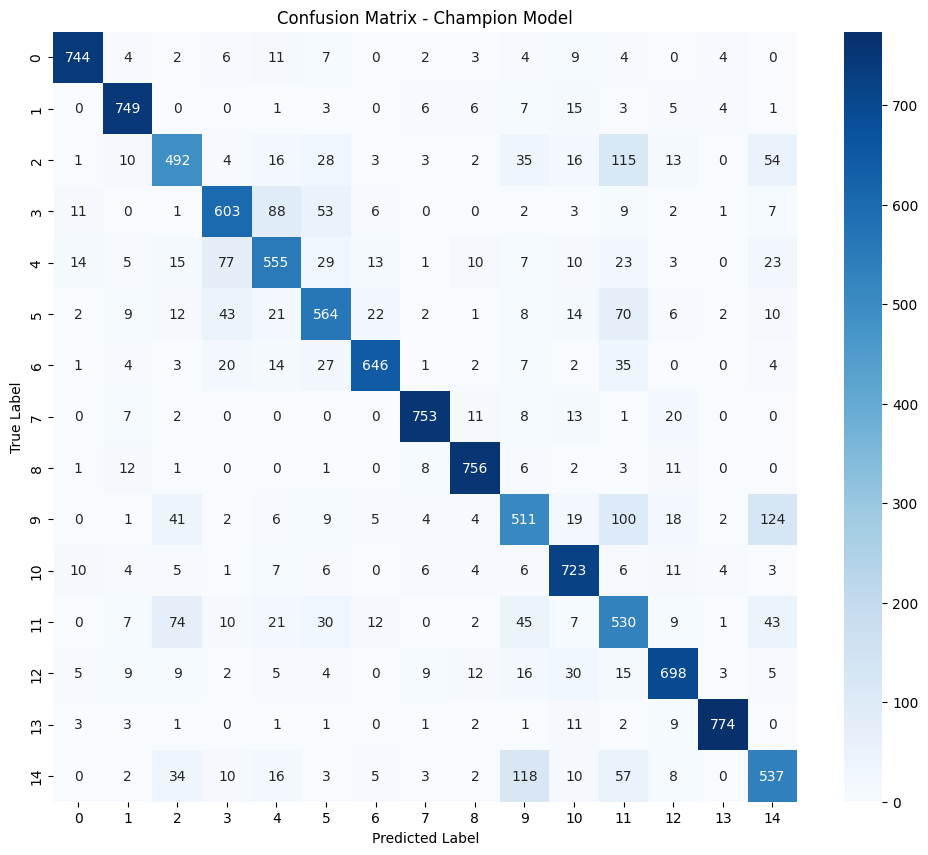

Top 2 Most Confused Pairs:
True Class 9 was predicted as Class 14 -> 124 times
True Class 14 was predicted as Class 9 -> 118 times


In [75]:
model = Champion()
model.load_state_dict(torch.load('best_model_champion7.pth'))
model.to(device)
model.eval()

all_preds = []
all_targets = []

# 2. Gather all predictions from the validation set
with torch.no_grad():
    for inputs, targets in val_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        preds = torch.argmax(outputs, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

# 3. Generate the Confusion Matrix
cm = confusion_matrix(all_targets, all_preds)

# Plotting
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Champion Model')
plt.show()

# 4. Find the Top 2 Confused Pairs
# Fill diagonal with 0s so we only look at mistakes
np.fill_diagonal(cm, 0)

# Flatten and get the indices of the highest errors
flat_cm = cm.flatten()
top_2_indices = flat_cm.argsort()[-2:][::-1]

print("Top 2 Most Confused Pairs:")
for idx in top_2_indices:
    true_class = idx // 15  # Assuming 15 classes
    pred_class = idx % 15
    mistakes = cm[true_class, pred_class]
    print(f"True Class {true_class} was predicted as Class {pred_class} -> {mistakes} times")

In [76]:
import torchvision.transforms as T

# Define a light augmentation pipeline
# Degrees: Rotate between -10 and +10 degrees
# Translate: Shift the image up/down/left/right by up to 10%
augment = T.Compose([
    T.RandomRotation(degrees=10),
    T.RandomAffine(degrees=0, translate=(0.1, 0.1))
])

In [77]:
# Added data augmentation, then will experiment with other changes if needed.
model = Champion().to(device)
optimizer = optim.AdamW(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

In [78]:
best_val_acc = 0.0

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        inputs_2d = inputs.view(-1, 1, 28, 28)
        
        augmented_2d = augment(inputs_2d)
        
        inputs = augmented_2d.view(-1, 784)
        optimizer.zero_grad()
        
        outputs = model(inputs) 
        loss = criterion(outputs, targets)
        
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, dim=1)
        correct_train += (preds == targets).sum().item()
        total_train += targets.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = correct_train / total_train

    model.eval()
    val_correct = 0
    val_total = 0
    val_loss = 0.0

    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            logits = model(inputs)
            loss = criterion(logits, targets)
            
            val_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(logits, dim=1)
            val_correct += (preds == targets).sum().item()
            val_total += targets.size(0)

    val_accuracy = val_correct / val_total if val_total > 0 else 0
    val_loss_avg = val_loss / len(val_loader.dataset) if len(val_loader.dataset) > 0 else 0

    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        best_epoch = epoch + 1
        torch.save(model.state_dict(), 'best_model_champion8.pth')
    val_loss_avg = val_loss / len(val_loader.dataset) if len(val_loader.dataset) > 0 else 0
    
    scheduler.step(val_loss_avg)
    
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Current Learning Rate: {current_lr}")
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc*100:.2f}%")
    print(f"Val Loss:   {val_loss_avg:.4f} | Val Acc:   {val_accuracy*100:.2f}%")
    print("-" * 30)
print(f"Best Validation Accuracy: {best_val_acc*100:.2f}% at epoch {best_epoch}")

Current Learning Rate: 0.001
Epoch 1/40
Train Loss: 1.7937 | Train Acc: 48.82%
Val Loss:   1.3857 | Val Acc:   65.12%
------------------------------
Current Learning Rate: 0.001
Epoch 2/40
Train Loss: 1.5690 | Train Acc: 58.25%
Val Loss:   1.3292 | Val Acc:   67.88%
------------------------------
Current Learning Rate: 0.001
Epoch 3/40
Train Loss: 1.5082 | Train Acc: 60.75%
Val Loss:   1.3118 | Val Acc:   68.53%
------------------------------
Current Learning Rate: 0.001
Epoch 4/40
Train Loss: 1.4774 | Train Acc: 62.16%
Val Loss:   1.2880 | Val Acc:   70.23%
------------------------------
Current Learning Rate: 0.001
Epoch 5/40
Train Loss: 1.4401 | Train Acc: 64.03%
Val Loss:   1.2446 | Val Acc:   71.78%
------------------------------
Current Learning Rate: 0.001
Epoch 6/40
Train Loss: 1.4124 | Train Acc: 65.06%
Val Loss:   1.2085 | Val Acc:   73.17%
------------------------------
Current Learning Rate: 0.001
Epoch 7/40
Train Loss: 1.3887 | Train Acc: 66.28%
Val Loss:   1.1965 | Val Ac

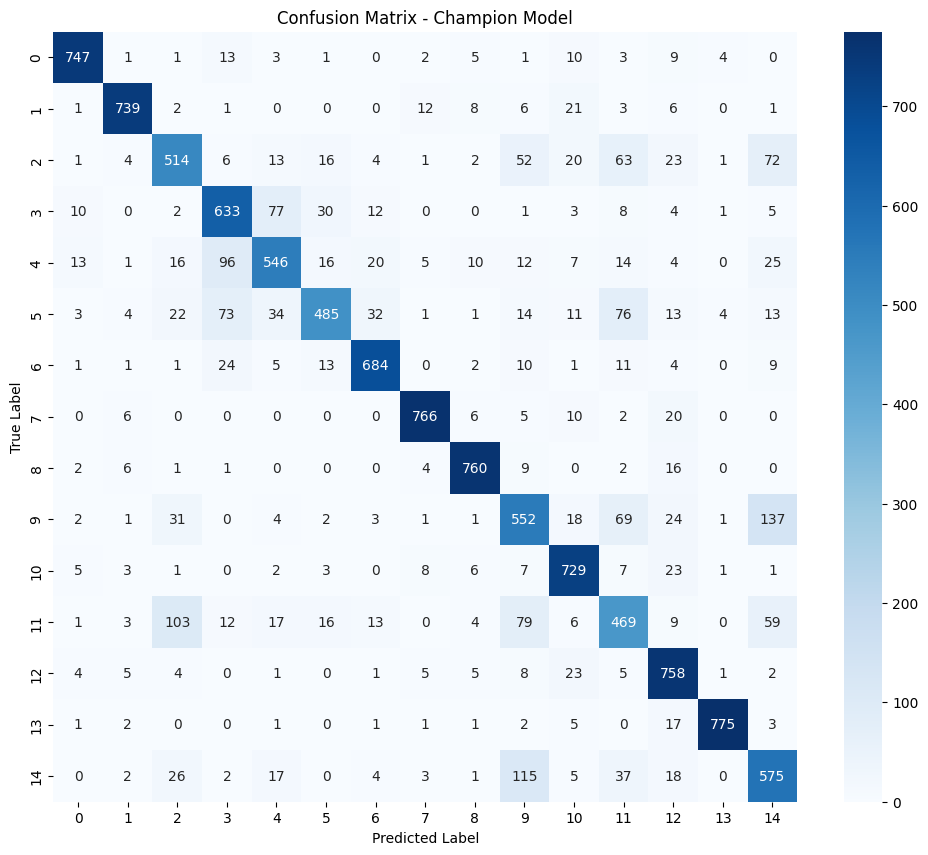

Top 2 Most Confused Pairs:
True Class 9 was predicted as Class 14 -> 137 times
True Class 14 was predicted as Class 9 -> 115 times


In [79]:
model = Champion()
model.load_state_dict(torch.load('best_model_champion8.pth'))
model.to(device)
model.eval()

all_preds = []
all_targets = []

# 2. Gather all predictions from the validation set
with torch.no_grad():
    for inputs, targets in val_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        
        outputs = model(inputs)
        preds = torch.argmax(outputs, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

# 3. Generate the Confusion Matrix
cm = confusion_matrix(all_targets, all_preds)

# Plotting
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Champion Model')
plt.show()

# 4. Find the Top 2 Confused Pairs
# Fill diagonal with 0s so we only look at mistakes
np.fill_diagonal(cm, 0)

# Flatten and get the indices of the highest errors
flat_cm = cm.flatten()
top_2_indices = flat_cm.argsort()[-2:][::-1]

print("Top 2 Most Confused Pairs:")
for idx in top_2_indices:
    true_class = idx // 15  # Assuming 15 classes
    pred_class = idx % 15
    mistakes = cm[true_class, pred_class]
    print(f"True Class {true_class} was predicted as Class {pred_class} -> {mistakes} times")

In [83]:
# Switched to one cycle LR, then will experiment with other changes if needed.
model = Champion().to(device)
optimizer = optim.AdamW(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=0.01, 
    epochs=40,
    steps_per_epoch=len(train_loader)
)

In [84]:
best_val_acc = 0.0

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        inputs_2d = inputs.view(-1, 1, 28, 28)
        
        augmented_2d = augment(inputs_2d)
        
        inputs = augmented_2d.view(-1, 784)
        optimizer.zero_grad()
        
        outputs = model(inputs) 
        loss = criterion(outputs, targets)
        
        loss.backward()
        optimizer.step()
        
        scheduler.step()
    
        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, dim=1)
        correct_train += (preds == targets).sum().item()
        total_train += targets.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = correct_train / total_train

    model.eval()
    val_correct = 0
    val_total = 0
    val_loss = 0.0

    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            logits = model(inputs)
            loss = criterion(logits, targets)
            
            val_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(logits, dim=1)
            val_correct += (preds == targets).sum().item()
            val_total += targets.size(0)

    val_accuracy = val_correct / val_total if val_total > 0 else 0
    val_loss_avg = val_loss / len(val_loader.dataset) if len(val_loader.dataset) > 0 else 0

    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        best_epoch = epoch + 1
        torch.save(model.state_dict(), 'best_model_champion9.pth')
    
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Current Learning Rate: {current_lr}")
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc*100:.2f}%")
    print(f"Val Loss:   {val_loss_avg:.4f} | Val Acc:   {val_accuracy*100:.2f}%")
    print("-" * 30)
print(f"Best Validation Accuracy: {best_val_acc*100:.2f}% at epoch {best_epoch}")

Current Learning Rate: 0.0005636283336392083
Epoch 1/40
Train Loss: 1.9452 | Train Acc: 42.72%
Val Loss:   1.4668 | Val Acc:   63.04%
------------------------------
Current Learning Rate: 0.001043357404736189
Epoch 2/40
Train Loss: 1.6430 | Train Acc: 55.10%
Val Loss:   1.3843 | Val Acc:   66.23%
------------------------------
Current Learning Rate: 0.0018064800180818252
Epoch 3/40
Train Loss: 1.5644 | Train Acc: 58.42%
Val Loss:   1.3546 | Val Acc:   66.33%
------------------------------
Current Learning Rate: 0.0028009676396827223
Epoch 4/40
Train Loss: 1.5099 | Train Acc: 60.84%
Val Loss:   1.2902 | Val Acc:   69.31%
------------------------------
Current Learning Rate: 0.003959017622727477
Epoch 5/40
Train Loss: 1.4881 | Train Acc: 62.11%
Val Loss:   1.3122 | Val Acc:   68.15%
------------------------------
Current Learning Rate: 0.0052016758884675315
Epoch 6/40
Train Loss: 1.4455 | Train Acc: 63.92%
Val Loss:   1.2338 | Val Acc:   72.36%
------------------------------
Current Lear

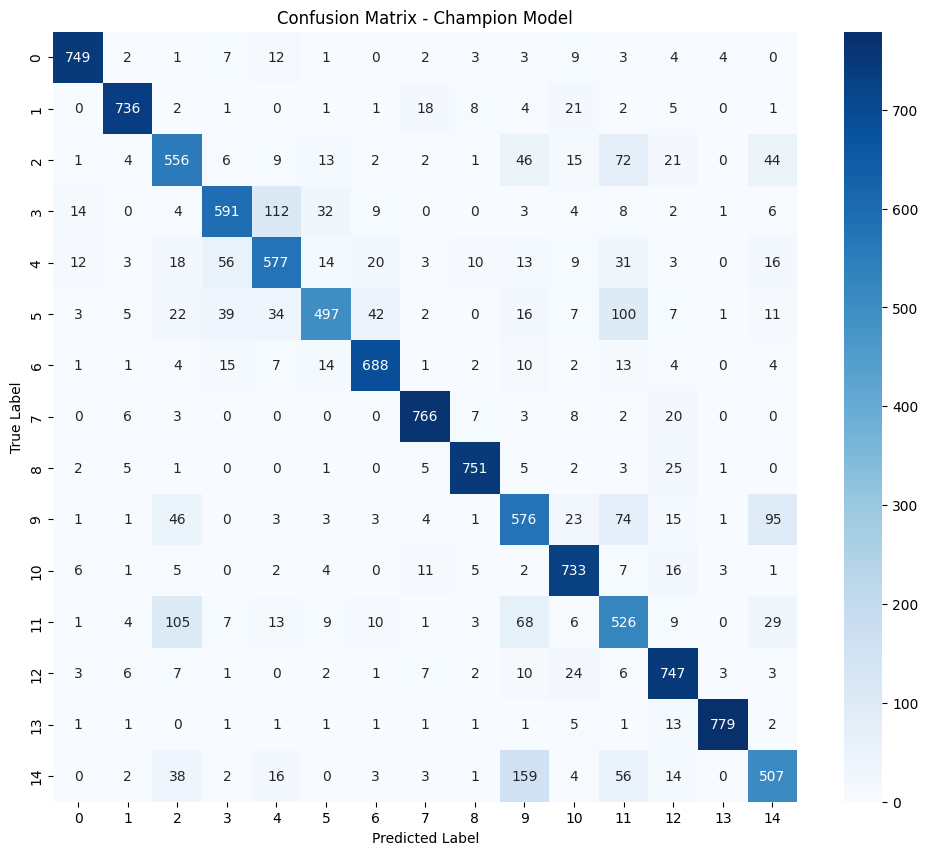

Top 2 Most Confused Pairs:
True Class 14 was predicted as Class 9 -> 159 times
True Class 3 was predicted as Class 4 -> 112 times


In [85]:
model = Champion()
model.load_state_dict(torch.load('best_model_champion9.pth'))
model.to(device)
model.eval()

all_preds = []
all_targets = []

# 2. Gather all predictions from the validation set
with torch.no_grad():
    for inputs, targets in val_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        
        outputs = model(inputs)
        preds = torch.argmax(outputs, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

# 3. Generate the Confusion Matrix
cm = confusion_matrix(all_targets, all_preds)

# Plotting
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Champion Model')
plt.show()

# 4. Find the Top 2 Confused Pairs
# Fill diagonal with 0s so we only look at mistakes
np.fill_diagonal(cm, 0)

# Flatten and get the indices of the highest errors
flat_cm = cm.flatten()
top_2_indices = flat_cm.argsort()[-2:][::-1]

print("Top 2 Most Confused Pairs:")
for idx in top_2_indices:
    true_class = idx // 15  # Assuming 15 classes
    pred_class = idx % 15
    mistakes = cm[true_class, pred_class]
    print(f"True Class {true_class} was predicted as Class {pred_class} -> {mistakes} times")

In [ ]:
# Added Graduated Dropout (0.2,0.3,0.4), then will experiment with other changes if needed.
model = Champion().to(device)
optimizer = optim.AdamW(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=0.01, 
    epochs=40,
    steps_per_epoch=len(train_loader)
)

In [ ]:
best_val_acc = 0.0

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        inputs_2d = inputs.view(-1, 1, 28, 28)
        
        augmented_2d = augment(inputs_2d)
        
        inputs = augmented_2d.view(-1, 784)
        optimizer.zero_grad()
        
        outputs = model(inputs) 
        loss = criterion(outputs, targets)
        
        loss.backward()
        optimizer.step()
        
        scheduler.step()
    
        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, dim=1)
        correct_train += (preds == targets).sum().item()
        total_train += targets.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = correct_train / total_train

    model.eval()
    val_correct = 0
    val_total = 0
    val_loss = 0.0

    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            logits = model(inputs)
            loss = criterion(logits, targets)
            
            val_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(logits, dim=1)
            val_correct += (preds == targets).sum().item()
            val_total += targets.size(0)

    val_accuracy = val_correct / val_total if val_total > 0 else 0
    val_loss_avg = val_loss / len(val_loader.dataset) if len(val_loader.dataset) > 0 else 0

    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        best_epoch = epoch + 1
        torch.save(model.state_dict(), 'best_model_champion10.pth')
    
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Current Learning Rate: {current_lr}")
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc*100:.2f}%")
    print(f"Val Loss:   {val_loss_avg:.4f} | Val Acc:   {val_accuracy*100:.2f}%")
    print("-" * 30)
print(f"Best Validation Accuracy: {best_val_acc*100:.2f}% at epoch {best_epoch}")

Current Learning Rate: 0.0005636283336392083
Epoch 1/40
Train Loss: 1.8554 | Train Acc: 46.68%
Val Loss:   1.4880 | Val Acc:   61.02%
------------------------------
Current Learning Rate: 0.001043357404736189
Epoch 2/40
Train Loss: 1.5720 | Train Acc: 58.16%
Val Loss:   1.3588 | Val Acc:   66.54%
------------------------------
Current Learning Rate: 0.0018064800180818252
Epoch 3/40
Train Loss: 1.5028 | Train Acc: 61.14%
Val Loss:   1.2979 | Val Acc:   69.27%
------------------------------
Current Learning Rate: 0.0028009676396827223
Epoch 4/40
Train Loss: 1.4536 | Train Acc: 63.21%
Val Loss:   1.2680 | Val Acc:   70.26%
------------------------------
Current Learning Rate: 0.003959017622727477
Epoch 5/40
Train Loss: 1.4161 | Train Acc: 64.99%
Val Loss:   1.2304 | Val Acc:   71.49%
------------------------------
Current Learning Rate: 0.0052016758884675315
Epoch 6/40
Train Loss: 1.3764 | Train Acc: 67.13%
Val Loss:   1.2129 | Val Acc:   72.83%
------------------------------
Current Lear

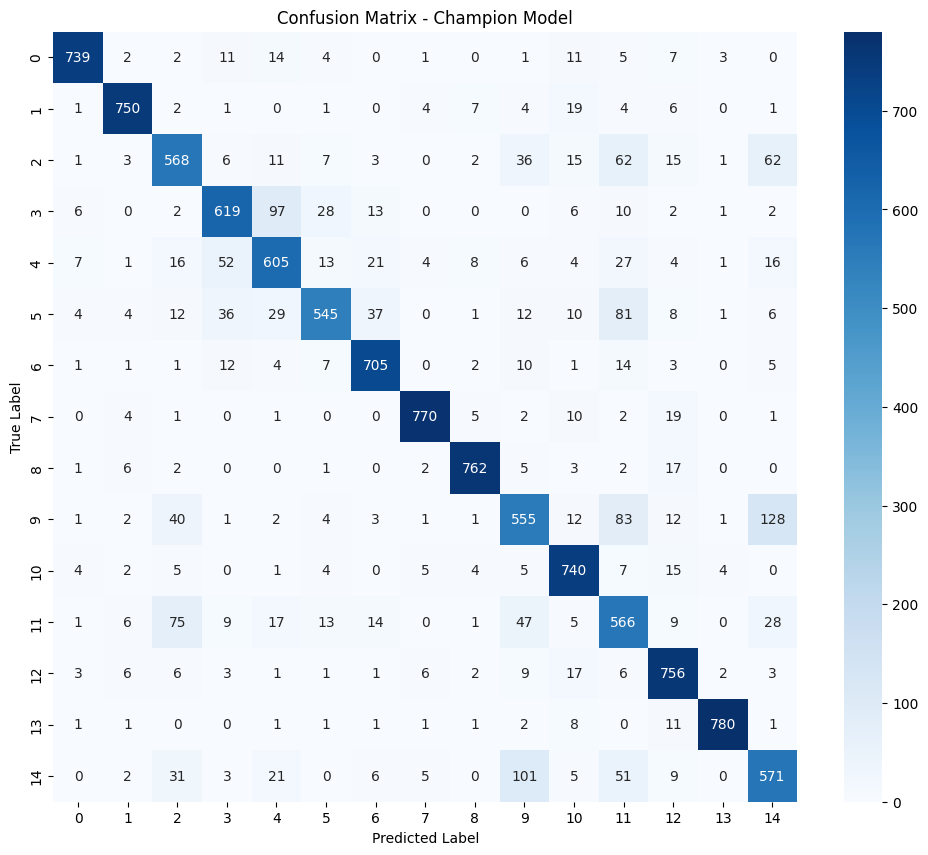

Top 2 Most Confused Pairs:
True Class 9 was predicted as Class 14 -> 128 times
True Class 14 was predicted as Class 9 -> 101 times


In [ ]:
model = Champion()
model.load_state_dict(torch.load('best_model_champion10.pth'))
model.to(device)
model.eval()

all_preds = []
all_targets = []

# 2. Gather all predictions from the validation set
with torch.no_grad():
    for inputs, targets in val_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        
        outputs = model(inputs)
        preds = torch.argmax(outputs, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

# 3. Generate the Confusion Matrix
cm = confusion_matrix(all_targets, all_preds)

# Plotting
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Champion Model')
plt.show()

# 4. Find the Top 2 Confused Pairs
# Fill diagonal with 0s so we only look at mistakes
np.fill_diagonal(cm, 0)

# Flatten and get the indices of the highest errors
flat_cm = cm.flatten()
top_2_indices = flat_cm.argsort()[-2:][::-1]

print("Top 2 Most Confused Pairs:")
for idx in top_2_indices:
    true_class = idx // 15  # Assuming 15 classes
    pred_class = idx % 15
    mistakes = cm[true_class, pred_class]
    print(f"True Class {true_class} was predicted as Class {pred_class} -> {mistakes} times")

In [90]:
# Added weight decay, then will experiment with other changes if needed.
model = Champion().to(device)
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-3)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=0.01, 
    epochs=40,
    steps_per_epoch=len(train_loader)
)

In [91]:
best_val_acc = 0.0

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        inputs_2d = inputs.view(-1, 1, 28, 28)
        
        augmented_2d = augment(inputs_2d)
        
        inputs = augmented_2d.view(-1, 784)
        optimizer.zero_grad()
        
        outputs = model(inputs) 
        loss = criterion(outputs, targets)
        
        loss.backward()
        optimizer.step()
        
        scheduler.step()
    
        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, dim=1)
        correct_train += (preds == targets).sum().item()
        total_train += targets.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = correct_train / total_train

    model.eval()
    val_correct = 0
    val_total = 0
    val_loss = 0.0

    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            logits = model(inputs)
            loss = criterion(logits, targets)
            
            val_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(logits, dim=1)
            val_correct += (preds == targets).sum().item()
            val_total += targets.size(0)

    val_accuracy = val_correct / val_total if val_total > 0 else 0
    val_loss_avg = val_loss / len(val_loader.dataset) if len(val_loader.dataset) > 0 else 0

    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        best_epoch = epoch + 1
        torch.save(model.state_dict(), 'best_model_champion11.pth')
    
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Current Learning Rate: {current_lr}")
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc*100:.2f}%")
    print(f"Val Loss:   {val_loss_avg:.4f} | Val Acc:   {val_accuracy*100:.2f}%")
    print("-" * 30)
print(f"Best Validation Accuracy: {best_val_acc*100:.2f}% at epoch {best_epoch}")

Current Learning Rate: 0.0005636283336392083
Epoch 1/40
Train Loss: 1.8690 | Train Acc: 46.68%
Val Loss:   1.4236 | Val Acc:   65.34%
------------------------------
Current Learning Rate: 0.001043357404736189
Epoch 2/40
Train Loss: 1.5675 | Train Acc: 58.56%
Val Loss:   1.3297 | Val Acc:   68.31%
------------------------------
Current Learning Rate: 0.0018064800180818252
Epoch 3/40
Train Loss: 1.5018 | Train Acc: 61.33%
Val Loss:   1.3123 | Val Acc:   68.08%
------------------------------
Current Learning Rate: 0.0028009676396827223
Epoch 4/40
Train Loss: 1.4434 | Train Acc: 63.72%
Val Loss:   1.2497 | Val Acc:   71.36%
------------------------------
Current Learning Rate: 0.003959017622727477
Epoch 5/40
Train Loss: 1.4200 | Train Acc: 65.12%
Val Loss:   1.2217 | Val Acc:   72.62%
------------------------------
Current Learning Rate: 0.0052016758884675315
Epoch 6/40
Train Loss: 1.3748 | Train Acc: 67.07%
Val Loss:   1.2004 | Val Acc:   73.26%
------------------------------
Current Lear

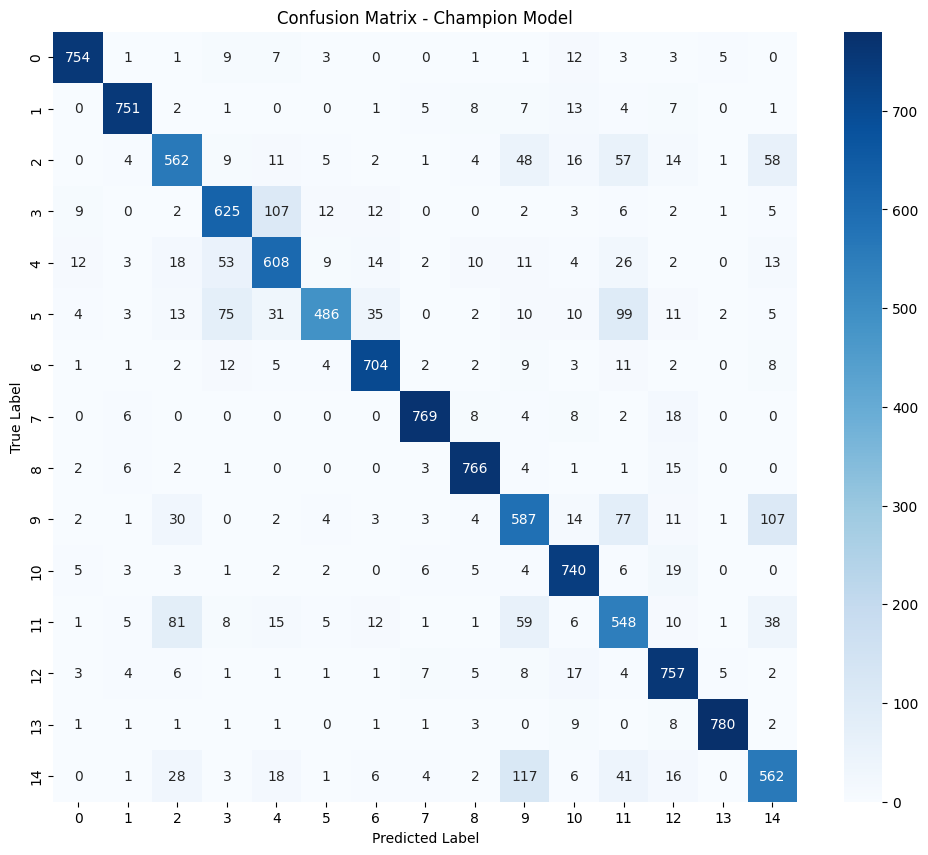

Top 2 Most Confused Pairs:
True Class 14 was predicted as Class 9 -> 117 times
True Class 9 was predicted as Class 14 -> 107 times


In [92]:
model = Champion()
model.load_state_dict(torch.load('best_model_champion11.pth'))
model.to(device)
model.eval()

all_preds = []
all_targets = []

# 2. Gather all predictions from the validation set
with torch.no_grad():
    for inputs, targets in val_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        
        outputs = model(inputs)
        preds = torch.argmax(outputs, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

# 3. Generate the Confusion Matrix
cm = confusion_matrix(all_targets, all_preds)

# Plotting
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Champion Model')
plt.show()

# 4. Find the Top 2 Confused Pairs
# Fill diagonal with 0s so we only look at mistakes
np.fill_diagonal(cm, 0)

# Flatten and get the indices of the highest errors
flat_cm = cm.flatten()
top_2_indices = flat_cm.argsort()[-2:][::-1]

print("Top 2 Most Confused Pairs:")
for idx in top_2_indices:
    true_class = idx // 15  # Assuming 15 classes
    pred_class = idx % 15
    mistakes = cm[true_class, pred_class]
    print(f"True Class {true_class} was predicted as Class {pred_class} -> {mistakes} times")

In [93]:
# Adjusted batch size to 256 and undo weight decay, then will experiment with other changes if needed.
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)
model = Champion().to(device)
optimizer = optim.AdamW(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=0.01, 
    epochs=40,
    steps_per_epoch=len(train_loader)
)

In [94]:
best_val_acc = 0.0

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        inputs_2d = inputs.view(-1, 1, 28, 28)
        
        augmented_2d = augment(inputs_2d)
        
        inputs = augmented_2d.view(-1, 784)
        optimizer.zero_grad()
        
        outputs = model(inputs) 
        loss = criterion(outputs, targets)
        
        loss.backward()
        optimizer.step()
        
        scheduler.step()
    
        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, dim=1)
        correct_train += (preds == targets).sum().item()
        total_train += targets.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = correct_train / total_train

    model.eval()
    val_correct = 0
    val_total = 0
    val_loss = 0.0

    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            logits = model(inputs)
            loss = criterion(logits, targets)
            
            val_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(logits, dim=1)
            val_correct += (preds == targets).sum().item()
            val_total += targets.size(0)

    val_accuracy = val_correct / val_total if val_total > 0 else 0
    val_loss_avg = val_loss / len(val_loader.dataset) if len(val_loader.dataset) > 0 else 0

    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        best_epoch = epoch + 1
        torch.save(model.state_dict(), 'best_model_champion12.pth')
    
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Current Learning Rate: {current_lr}")
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc*100:.2f}%")
    print(f"Val Loss:   {val_loss_avg:.4f} | Val Acc:   {val_accuracy*100:.2f}%")
    print("-" * 30)
print(f"Best Validation Accuracy: {best_val_acc*100:.2f}% at epoch {best_epoch}")

Current Learning Rate: 0.0005637002963685914
Epoch 1/40
Train Loss: 1.9572 | Train Acc: 43.00%
Val Loss:   1.4713 | Val Acc:   62.59%
------------------------------
Current Learning Rate: 0.0010436354408780522
Epoch 2/40
Train Loss: 1.6179 | Train Acc: 56.34%
Val Loss:   1.3903 | Val Acc:   65.78%
------------------------------
Current Learning Rate: 0.0018070697979475844
Epoch 3/40
Train Loss: 1.5164 | Train Acc: 60.57%
Val Loss:   1.3034 | Val Acc:   69.36%
------------------------------
Current Learning Rate: 0.0028019306881979216
Epoch 4/40
Train Loss: 1.4671 | Train Acc: 62.46%
Val Loss:   1.3138 | Val Acc:   68.88%
------------------------------
Current Learning Rate: 0.0039603601855542694
Epoch 5/40
Train Loss: 1.4146 | Train Acc: 65.26%
Val Loss:   1.2681 | Val Acc:   70.05%
------------------------------
Current Learning Rate: 0.0052033436016668995
Epoch 6/40
Train Loss: 1.3878 | Train Acc: 66.42%
Val Loss:   1.2069 | Val Acc:   73.36%
------------------------------
Current Le

In [95]:
count_parameters(model)

569871

In [96]:
def generate_final_submission(model, test_loader, augment_fn, num_passes=5):
    model.eval() 
    all_predictions = []
    
    print(f"Starting TTA Inference with {num_passes} passes...")
    
    with torch.no_grad():
        for i, inputs in enumerate(test_loader):
            # Handle TensorDataset wrapping
            if isinstance(inputs, (list, tuple)):
                inputs = inputs[0]
            
            inputs = inputs.to(device)
            inputs_2d = inputs.view(-1, 1, 28, 28)
            
            # Accumulate raw scores (logits)
            accumulated_logits = torch.zeros(inputs.size(0), 15).to(device)
            
            # Pass 1: Original image
            accumulated_logits += model(inputs)
            
            # Passes 2-N: Augmented versions
            for _ in range(num_passes - 1):
                aug_2d = augment_fn(inputs_2d)
                aug_flat = aug_2d.view(-1, 784)
                accumulated_logits += model(aug_flat)
                
            # Average and find the most confident class
            preds = torch.argmax(accumulated_logits, dim=1)
            all_predictions.extend(preds.cpu().numpy())
            
            if (i + 1) % 50 == 0:
                print(f"Processed {len(all_predictions)} test samples...")

    # Join with commas: 0, 1, 0, 12...
    csv_string = ",".join(map(str, all_predictions))
    
    with open("final_submission.txt", "w") as f:
        f.write(csv_string)
        
    print("\nSubmission string generated successfully!")
    print(f"Total Predictions: {len(all_predictions)}")
    print("Check 'final_submission.txt' for your string.")
    print(csv_string)
# 1. Initialize model with your [1024, 512, 256] structure
model = Champion() 

# 2. Load the best weights from your peak at Epoch 38
model.load_state_dict(torch.load('best_model_champion9.pth'))
model.to(device)

# 3. Generate the file (Ensure test_loader has shuffle=False!)
generate_final_submission(model, test_loader, augment, num_passes=5)

Starting TTA Inference with 5 passes...
Processed 6400 test samples...
Processed 12800 test samples...

Submission string generated successfully!
Total Predictions: 15000
Check 'final_submission.txt' for your string.
6,11,5,8,0,1,11,9,14,8,9,7,11,11,13,8,13,12,11,3,13,6,14,8,0,13,13,2,6,5,14,11,1,12,13,5,11,5,8,2,12,8,0,2,13,1,14,14,10,1,3,11,0,9,11,11,11,6,10,9,14,6,1,2,0,12,11,12,4,11,4,6,3,14,13,6,5,6,11,11,10,13,6,4,12,0,0,2,14,11,0,7,1,14,3,6,3,12,9,10,14,12,1,4,5,9,7,4,14,11,9,1,1,13,12,2,1,7,9,0,4,7,9,2,13,13,7,14,3,4,5,6,0,8,11,11,11,12,1,13,10,2,1,9,1,12,7,2,3,0,4,14,1,12,6,10,0,4,9,6,0,9,5,13,9,13,5,9,1,5,12,10,4,4,13,7,14,6,7,11,2,13,10,3,12,3,8,6,11,1,9,14,8,6,0,4,1,5,5,10,6,14,10,1,13,1,1,10,5,7,14,11,1,11,6,2,6,3,8,1,1,4,12,12,9,11,13,14,4,0,11,6,4,14,1,3,10,0,11,4,9,2,4,12,4,9,5,0,6,7,6,5,7,1,13,5,1,9,0,4,13,0,7,4,6,4,12,12,3,7,13,11,11,4,10,8,12,8,6,6,1,7,12,12,0,3,14,4,12,4,6,6,2,0,9,12,9,6,2,8,5,12,3,0,6,11,11,7,13,8,12,13,12,1,5,3,9,10,14,13,0,9,12,11,7,9,3,10,11,12,

In [143]:
def initialize_weights(m):
    if isinstance(m, nn.Linear):
        # Apply Kaiming Normal initialization to weights
        # non-linearity='leaky_relu' or 'relu' is standard for GELU as well
        nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
        
        # Initialize biases to zero
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)
    
    elif isinstance(m, nn.BatchNorm1d):
        # BatchNorm layers should be initialized to 1 for weight and 0 for bias
        nn.init.constant_(m.weight, 1)
        nn.init.constant_(m.bias, 0)

In [149]:
# Ensemble Training
num_models = 5
ensemble_paths3 = []
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)
for i in range(num_models):
    print(f"\n--- Training Model {i+1}/{num_models} ---")
    
    # Re-initialize model, optimizer, and scheduler for each run
    model = Champion(hidden_layers=[512, 512, 256]).to(device) 
    optimizer = torch.optim.AdamW(model.parameters(), lr=0.01)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=0.02, epochs=40, steps_per_epoch=len(train_loader)
    )
    
    best_val_acc = 0.0
    save_path = f'model_ensemble_{i}_init.pth'
    
    for epoch in range(40):
        model.train()
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            # Apply your Data Augmentation injection here
            inputs = augment(inputs.view(-1, 1, 28, 28)).view(-1, 784)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            scheduler.step()

        # Simple validation check to save the best version of THIS model
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                preds = torch.argmax(outputs, dim=1)
                correct += (preds == targets).sum().item()
                total += targets.size(0)
        
        val_acc = correct / total
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch + 1
            torch.save(model.state_dict(), save_path)
            
    print(f"Model {i+1} Best Val Acc: {best_val_acc*100:.2f}% at epoch {best_epoch}")
    print(f"Number of parameters of model {i+1}: {count_parameters(model)}")
    ensemble_paths3.append(save_path)


--- Training Model 1/5 ---
Model 1 Best Val Acc: 84.68% at epoch 38
Number of parameters of model 1: 802319

--- Training Model 2/5 ---
Model 2 Best Val Acc: 84.64% at epoch 40
Number of parameters of model 2: 802319

--- Training Model 3/5 ---
Model 3 Best Val Acc: 84.76% at epoch 38
Number of parameters of model 3: 802319

--- Training Model 4/5 ---
Model 4 Best Val Acc: 84.75% at epoch 39
Number of parameters of model 4: 802319

--- Training Model 5/5 ---
Model 5 Best Val Acc: 84.06% at epoch 39
Number of parameters of model 5: 802319


In [130]:
val_loader = DataLoader(val_dataset, batch_size=512, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False)

In [150]:
def validate_ensemble_tta(models, val_loader, augment_fn, num_tta_passes=10):
    for m in models: m.eval()
    
    val_correct = 0
    val_total = 0
    
    print(f"Running Ensemble TTA on Validation ({num_tta_passes} passes)...")
    
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            inputs_2d = inputs.view(-1, 1, 28, 28)
            
            # Accumulated logits for the whole batch
            combined_logits = torch.zeros(inputs.size(0), 15).to(device)
            
            for m in models:
                # 1. Original View
                combined_logits += m(inputs)
                
                # 2. Augmented Views
                for _ in range(num_tta_passes - 1):
                    aug_flat = augment_fn(inputs_2d).view(-1, 784)
                    combined_logits += m(aug_flat)
            
            # Take the final vote
            preds = torch.argmax(combined_logits, dim=1)
            val_correct += (preds == targets).sum().item()
            val_total += targets.size(0)

    final_val_acc = val_correct / val_total
    print(f"\nFinal Ensemble + TTA Validation Accuracy: {final_val_acc*100:.2f}%")
    return final_val_acc

# Run the check
# 'models' should be your list of 5 loaded Champion models
# models = []
# for path in ensemble_paths:
#     m = Champion(hidden_layers=[512, 512, 256]).to(device)
#     m.load_state_dict(torch.load(path))
#     models.append(m)
# validate_ensemble_tta(models, val_loader, augment, num_tta_passes=10)
# models = []
# for path in ensemble_paths2:
#     m = Champion(hidden_layers=[512, 512, 256]).to(device)
#     m.load_state_dict(torch.load(path))
#     models.append(m)
# validate_ensemble_tta(models, val_loader, augment, num_tta_passes=10)
models = []
for path in ensemble_paths3:
    m = Champion(hidden_layers=[512, 512, 256]).to(device)
    m.load_state_dict(torch.load(path))
    models.append(m)
validate_ensemble_tta(models, val_loader, augment, num_tta_passes=10)

Running Ensemble TTA on Validation (10 passes)...

Final Ensemble + TTA Validation Accuracy: 84.08%


0.8408333333333333

In [152]:
def generate_ensemble_tta_submission(model_paths, test_loader, augment_fn, num_tta_passes=10):
    models = []
    for path in model_paths:
        m = Champion(hidden_layers=[512, 512, 256]).to(device)
        m.load_state_dict(torch.load(path))
        m.eval()
        models.append(m)
    
    all_predictions = []
    with torch.no_grad():
        for inputs in test_loader:
            if isinstance(inputs, (list, tuple)): inputs = inputs[0]
            inputs = inputs.to(device)
            inputs_2d = inputs.view(-1, 1, 28, 28)
            
            # Sum logits from ALL models and ALL TTA passes
            combined_logits = torch.zeros(inputs.size(0), 15).to(device)
            
            for m in models:
                # Original pass
                combined_logits += m(inputs)
                # TTA passes
                for _ in range(num_tta_passes - 1):
                    aug_flat = augment_fn(inputs_2d).view(-1, 784)
                    combined_logits += m(aug_flat)
            
            preds = torch.argmax(combined_logits, dim=1)
            all_predictions.extend(preds.cpu().numpy())

    csv_string = ",".join(map(str, all_predictions))
    with open("ensemble_submission.txt", "w") as f:
        f.write(csv_string)
    print("Ensemble TTA submission generated!")
    print(csv_string)

# Run it!
generate_ensemble_tta_submission(ensemble_paths3, test_loader, augment)

Ensemble TTA submission generated!
6,11,5,8,0,1,11,9,14,8,9,7,11,11,13,8,13,12,11,3,13,6,14,8,0,13,13,2,6,5,14,11,1,12,13,5,11,5,8,2,12,8,0,2,13,1,11,9,10,1,3,11,0,11,11,11,11,6,10,9,9,6,7,2,0,12,11,12,4,11,4,6,3,14,13,6,5,6,11,11,10,13,6,4,12,0,0,2,14,11,0,7,1,14,3,6,3,12,9,10,14,12,1,4,5,9,7,4,11,11,9,1,1,13,12,2,1,7,9,0,4,7,14,2,13,13,7,14,3,4,5,3,0,8,9,11,11,12,1,13,10,2,1,9,1,12,7,2,3,0,4,14,1,12,6,8,0,4,9,6,0,9,5,13,9,13,11,9,1,5,12,10,4,4,13,7,14,6,7,11,2,13,10,3,12,3,8,6,11,1,9,14,8,6,0,4,1,5,5,10,6,14,10,1,13,1,1,10,5,7,14,11,1,11,6,2,6,4,8,1,1,4,7,12,9,11,13,14,4,0,11,6,4,14,1,3,10,0,11,4,9,2,4,12,4,9,5,0,6,7,6,5,7,1,13,5,1,9,0,4,13,0,7,4,6,4,12,12,3,7,13,9,11,4,10,8,12,8,6,6,1,7,12,12,0,3,14,4,12,4,6,6,2,0,9,12,9,6,2,8,5,12,3,0,6,11,11,7,13,8,12,13,12,1,5,3,9,10,14,13,0,9,12,11,7,9,0,10,11,12,13,12,6,3,2,14,7,8,10,1,11,10,2,1,10,14,12,14,0,7,7,0,10,7,3,7,12,1,7,12,2,13,4,11,5,14,11,8,7,11,12,11,4,13,1,14,4,2,0,13,9,3,10,9,6,0,11,10,10,2,2,5,14,11,3,11,13,10,4,13,9,4,8,7,13,9